In [5]:
# Essentail Imports for Pytorch Dataloader

#Essentails
import os
import json
from PIL import Image
from matplotlib import pyplot as plt

#pytorch imports
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [6]:
#print paths:
#os.listdir('../data')

with open('../data/instances_train2019.json', 'r') as f:
    temp_data = json.load(f)

temp_data['annotations'][0]

{'area': 111763.29,
 'bbox': [1188.4, 1052.45, 390.96, 285.87],
 'category_id': 112,
 'id': 0,
 'image_id': 0,
 'iscrowd': 0,
 'segmentation': [[]],
 'point_xy': [1383.88, 1195.38]}

### Custom DataSet Class (Normal Transformers)

In [7]:
# Define the custom dataset class
class CustomDatasetClass(Dataset):
    '''
    '''

    #Init function.
    def __init__(self,images_dir, json_path, transforms=None):
        self.images_dir = images_dir
        self.transforms = transforms

        # Load the JSON file:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        self.images = data['images']
        self.annotations = data['annotations']
        self.categories = data['categories']


        #pre-map the annotation to image_ID for faster access later O(n) instead of looping later:

        ''' Annotation Structure for an image
        {'area': 111763.29,
        'bbox': [1188.4, 1052.45, 390.96, 285.87],
        'category_id': 112,
        'id': 0,
        'image_id': 0,
        'iscrowd': 0,
        'segmentation': [[]],
        'point_xy': [1383.88, 1195.38]}
        '''

        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']

            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)
            

    #len function:
    def __len__(self):
        return len(self.images)

    #getitem function:,
    def __getitem__(self,idx):
        img_info = self.images[idx] # Image entries: {'file_name': '038900004095_camera0-13.jpg', 'width': 2592, 'height': 1944, 'id': 0}
        img_id = img_info['id']

        img_name = img_info['file_name']

        full_path = os.path.join(self.images_dir, img_name)

        image = Image.open(full_path).convert('RGB')


        #Now we got the image and opened it. time to extract the features (annotations):
        #retrieve the pre-stored anns
        anns = self.img_to_anns.get(img_id, [])

        boxes,labels = [],[]

        for ann in anns:
            #convert COCO to Pytorch: [x,y,w,h] -> [x1,y1,x2,y2]

            x,y,w,h = ann['bbox']
            boxes.append([x, y, (x+w), (y+h)])
            labels.append(ann['category_id'])


        #convert EVERYTHING to Tensors:
        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([img_id])
        }

        # Apply transformations
        if self.transforms:
            # For detection, transforms often need both image and target
            image, target = self.transforms(image, target)

        return image, target



In [8]:
# Define paths for clarity
DATA_ROOT = "../data/"

# Create instances for each split
train_dataset = CustomDatasetClass(
    images_dir=os.path.join(DATA_ROOT, "train2019"),
    json_path=os.path.join(DATA_ROOT, "instances_train2019.json"),
)

val_dataset = CustomDatasetClass(
    images_dir=os.path.join(DATA_ROOT, "val2019"),
    json_path=os.path.join(DATA_ROOT, "instances_val2019.json")
)

test_dataset = CustomDatasetClass(
    images_dir = os.path.join(DATA_ROOT, 'test2019'),
    json_path = os.path.join(DATA_ROOT, 'instances_test2019.json')
)

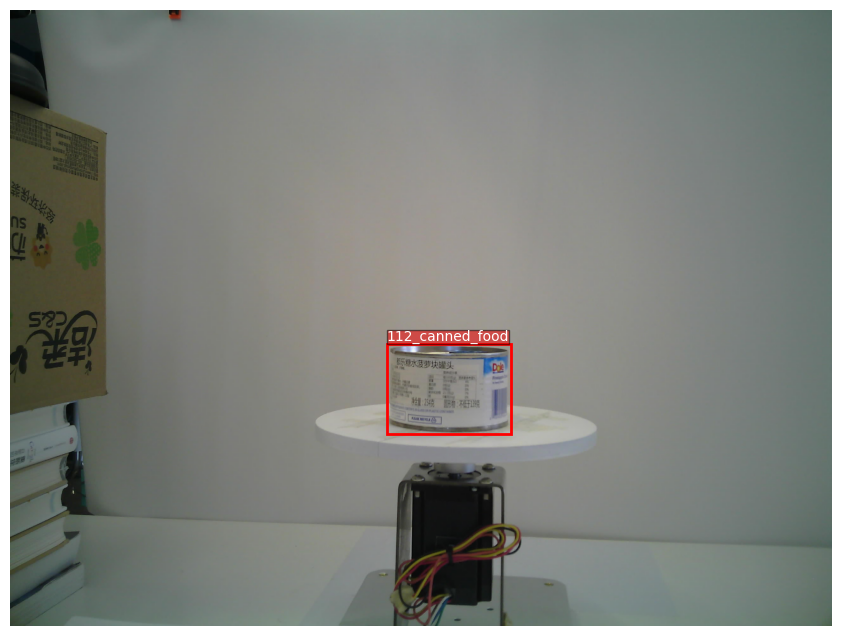

In [9]:
# 1. تجهيز القاموس باستخدام self.categories الجديد
id_to_name = {cat['id']: cat['name'] for cat in train_dataset.categories}

# 2. استخراج عينة
img, tar = train_dataset[0]

# 3. دالة الرسم (تأكد من عمل import لـ matplotlib.patches)
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_sample_pro(image, target, id_map):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    
    # تحويل من Tensor إلى Numpy Array للرسم
    if torch.is_tensor(image):
        # PIL Images are already HWC, Tensors are CHW
        # if you didn't apply ToTensor yet, it might stay as PIL
        import numpy as np
        image = np.array(image)
    
    ax.imshow(image)
    
    boxes = target['boxes']
    labels = target['labels']
    
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box.tolist() # تحويل لـ list عشان نطلع الأرقام
        width, height = x2 - x1, y2 - y1
        
        class_name = id_map.get(label.item(), f"ID: {label.item()}")
        
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1, class_name, color='white', verticalalignment='bottom',
                bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 0})
    
    plt.axis('off')
    plt.show()

visualize_sample_pro(img, tar, id_to_name)

### Custom Dataset Class with Test Time Augmentation 'TTA' using (Albeumintation)

In [21]:
#Augmentation imports
import numpy as np
import albumentations as A #Main Augmentations Library
from albumentations.pytorch import ToTensorV2

# Define the custom dataset class
class CustomAugmentationClass(Dataset):
    '''
    '''

    #Init function.
    def __init__(self,images_dir, json_path, transforms=None):
        self.images_dir = images_dir
        self.transforms = transforms

        # Load the JSON file:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        self.images = data['images']
        self.annotations = data['annotations']
        self.categories = data['categories']


        #pre-map the annotation to image_ID for faster access later O(n) instead of looping later:

        ''' Annotation Structure for an image
        {'area': 111763.29,
        'bbox': [1188.4, 1052.45, 390.96, 285.87],
        'category_id': 112,
        'id': 0,
        'image_id': 0,
        'iscrowd': 0,
        'segmentation': [[]],
        'point_xy': [1383.88, 1195.38]}
        '''

        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']

            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)
            

    #len function:
    def __len__(self):
        return len(self.images)

    #getitem function:
    def __getitem__(self,idx):
        img_info = self.images[idx] # Image entries: {'file_name': '038900004095_camera0-13.jpg', 'width': 2592, 'height': 1944, 'id': 0}
        img_id = img_info['id']

        img_name = img_info['file_name']

        full_path = os.path.join(self.images_dir, img_name)

        #1- Albumentations only accepts numpy arrays
        image = Image.open(full_path).convert('RGB')
        image = np.array(image)

        #2- time to extract the features (annotations):

        #retrieve the pre-stored anns
        anns = self.img_to_anns.get(img_id, [])

        boxes,labels = [],[]

        for ann in anns:
            #convert COCO to Pytorch: [x,y,w,h] -> [x1,y1,x2,y2]

            x,y,w,h = ann['bbox']
            boxes.append([x, y, (x+w), (y+h)])
            labels.append(ann['category_id'])

        #3- apply transformations with Albumentations.
        if self.transforms:
            transformed = self.transforms(image=image, bboxes=boxes, category_ids=labels)
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['category_ids']



        #4- convert EVERYTHING to Tensors (after Transformation)
        #and handle empty boxes just in case:
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        
        #5- Define target (as a Dictionary !!!)
        target = {
            'boxes':boxes,
            'labels':labels,
            'image_id':torch.tensor([img_id])
        }


        return image, target
 

In [22]:
train_transformers = A.Compose([
    A.Resize(640,640),
    A.HorizontalFlip(p=0.3),
    A.GaussianBlur(blur_limit=3, p=1.0),
    A.RandomRotate90(p=0.2),
    A.ColorJitter(p=0.2),
    ToTensorV2()
], 
bbox_params=A.BboxParams(coord_format='pascal_voc', label_fields=['category_ids'])
)

val_test_transformers = A.Compose([
    A.Resize(640, 640),
    ToTensorV2()
], bbox_params=A.BboxParams(coord_format='pascal_voc', label_fields=['category_ids'])
)


# Create DataLoaders
train_dataset = CustomAugmentationClass(
    images_dir=os.path.join(DATA_ROOT, "train2019"),
    json_path=os.path.join(DATA_ROOT, "instances_train2019.json"),
    transforms=train_transformers
)

val_dataset = CustomAugmentationClass(
    images_dir=os.path.join(DATA_ROOT, "val2019"),
    json_path=os.path.join(DATA_ROOT, "instances_val2019.json"),
    transforms=val_test_transformers
)

test_dataset = CustomAugmentationClass(
    images_dir=os.path.join(DATA_ROOT, "test2019"),
    json_path=os.path.join(DATA_ROOT, "instances_test2019.json"),
    transforms=val_test_transformers
)


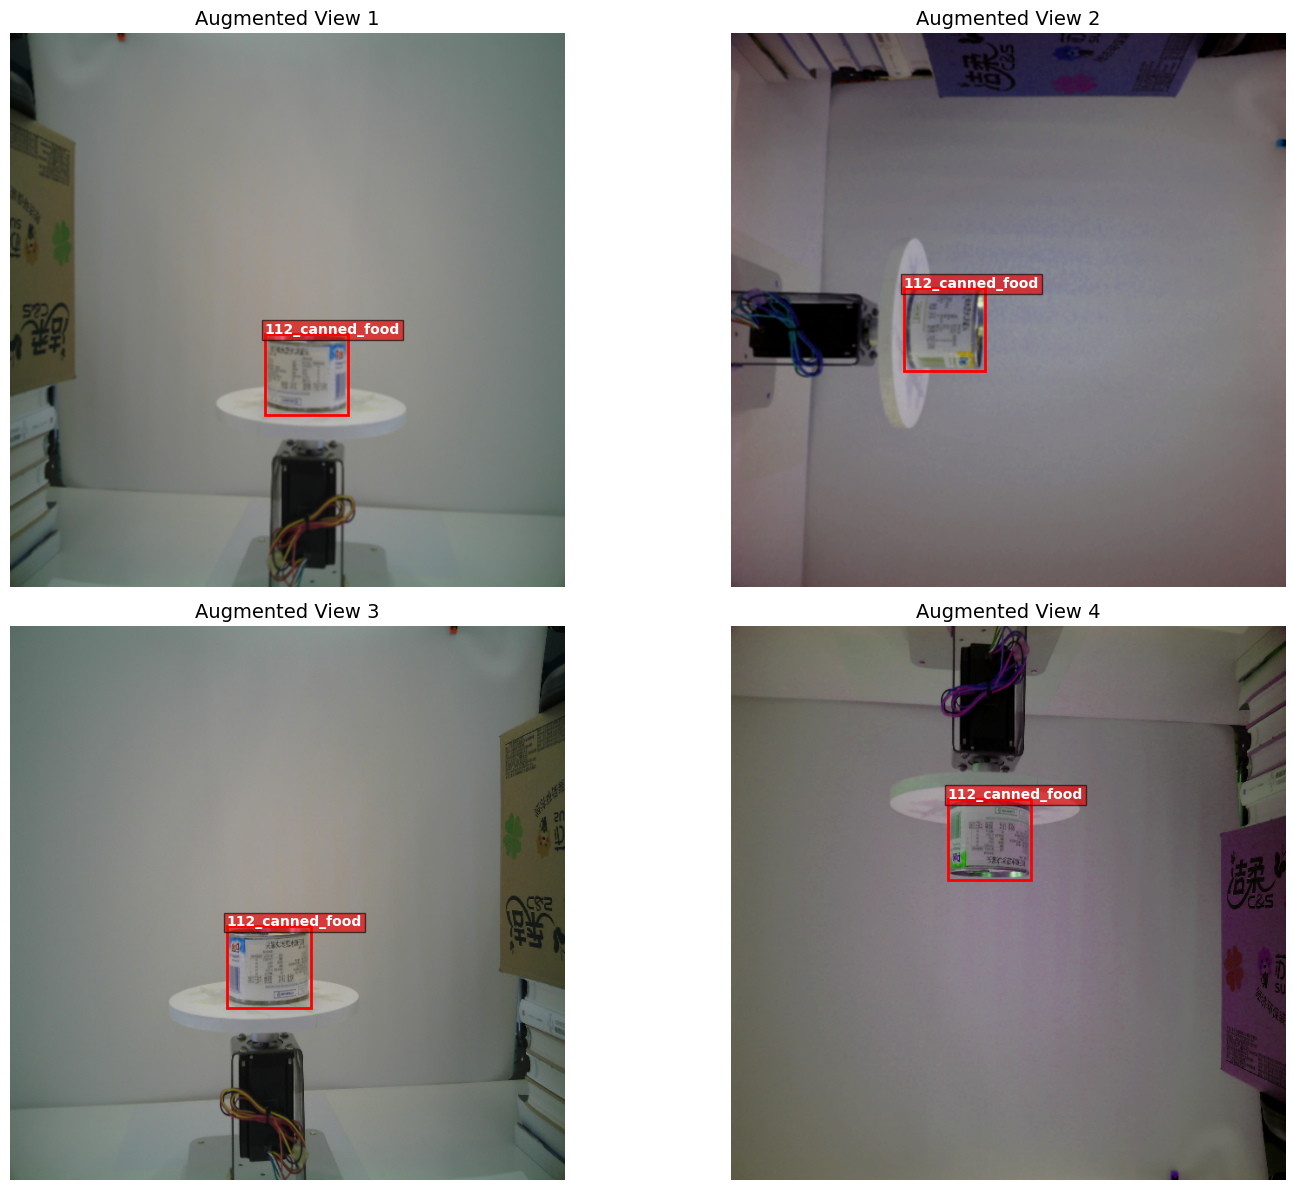

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_augmentations_grid(dataset, id_map, num_samples=4, rows=2):
    cols = num_samples // rows
    # Increase figsize to give each image more breathing room
    fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
    
    # Flatten axes array to easily loop through them in 1D
    axes_flat = axes.flatten()
    
    for i in range(num_samples):
        # Fetch a sample (calling __getitem__)
        image, target = dataset[0] 
        
        # Convert Tensor (CHW) to NumPy (HWC) if needed
        if torch.is_tensor(image):
            image = image.permute(1, 2, 0).cpu().numpy()
        
        axes_flat[i].imshow(image)
        
        boxes = target['boxes']
        labels = target['labels']
        
        # Draw each bounding box
        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box.tolist()
            width, height = x2 - x1, y2 - y1
            
            # Map ID to name
            class_name = id_map.get(label.item(), f"ID: {label.item()}")
            
            rect = patches.Rectangle(
                (x1, y1), width, height, 
                linewidth=2, edgecolor='r', facecolor='none'
            )
            axes_flat[i].add_patch(rect)
            
            # Put label name above the box
            axes_flat[i].text(
                x1, y1, class_name, color='white', fontsize=10, weight='bold',
                bbox={'facecolor': 'red', 'alpha': 0.6, 'pad': 2}
            )
        
        axes_flat[i].set_title(f"Augmented View {i+1}", fontsize=14)
        axes_flat[i].axis('off')
    
    # Adjust layout to prevent overlapping
    plt.tight_layout()
    plt.show()

# Run the updated grid visualizer
id_to_name = {cat['id']: cat['name'] for cat in train_dataset.categories}
visualize_augmentations_grid(train_dataset, id_to_name, num_samples=4, rows=2)